Shape after cleaning: (11233, 2)

Example rows:
                                                body    category
0  I often find myself checking on old friends on...  Depression
1  this is not a post asking if i have add depres...        ADHD
2  i went to my gp the other day to pick a new pr...        ADHD
3  im a morning person and always envied stories ...        ADHD
4  im preparing to be rediagnosed for adhd as im ...        ADHD

Original label distribution:
category
ADHD             2003
Anxiety          1904
Bipolar          1821
BPD              1617
Autism           1493
Depression       1432
schizophrenia     963
Name: count, dtype: int64


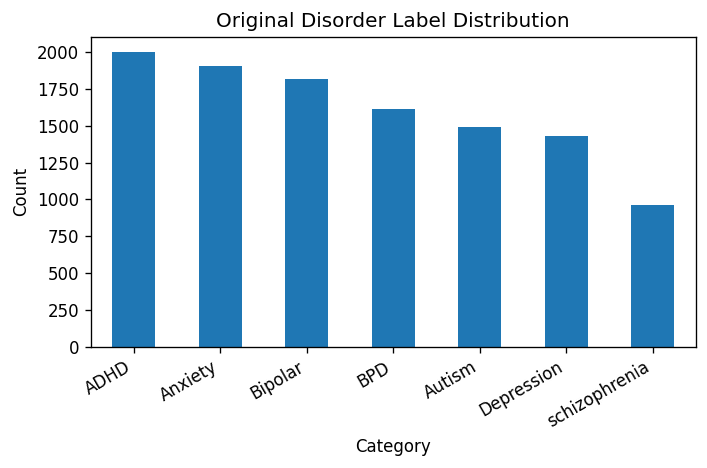


Binary label distribution (target):
target
Other         9801
Depression    1432
Name: count, dtype: int64


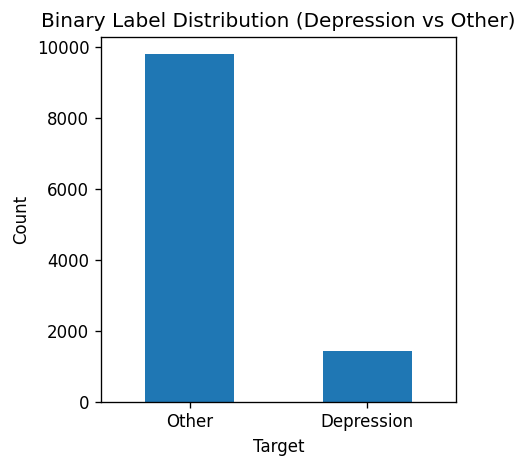


Train size: 8986
Test size : 2247

Training & Evaluating: Logistic Regression

Accuracy: 0.9008

Classification Report:
              precision    recall  f1-score   support

  Depression       0.58      0.78      0.67       286
       Other       0.97      0.92      0.94      1961

    accuracy                           0.90      2247
   macro avg       0.77      0.85      0.80      2247
weighted avg       0.92      0.90      0.91      2247


Training & Evaluating: Linear SVM

Accuracy: 0.9105

Classification Report:
              precision    recall  f1-score   support

  Depression       0.64      0.67      0.66       286
       Other       0.95      0.94      0.95      1961

    accuracy                           0.91      2247
   macro avg       0.80      0.81      0.80      2247
weighted avg       0.91      0.91      0.91      2247


Training & Evaluating: Naive Bayes

Accuracy: 0.8727

Classification Report:
              precision    recall  f1-score   support

  Depression   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

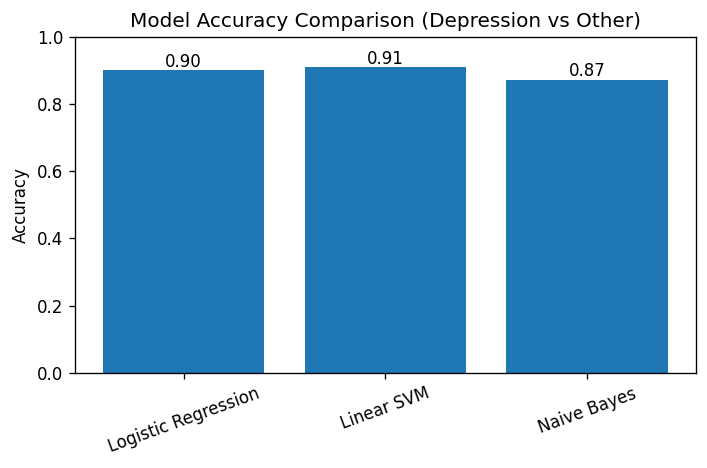


Final Accuracies:
Logistic Regression  -> 0.9008
Linear SVM           -> 0.9105
Naive Bayes          -> 0.8727


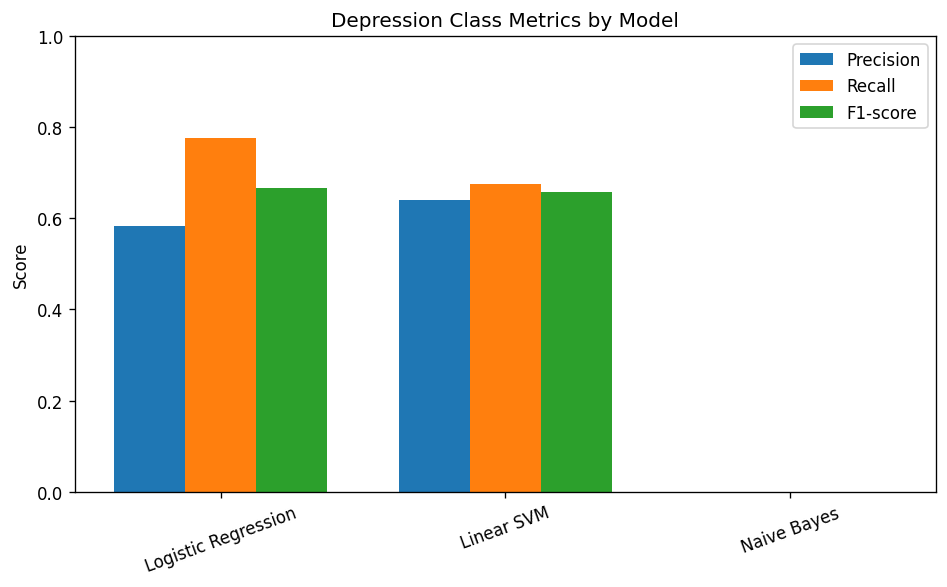

/tmp/ipykernel_3276/1816365000.py:224: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


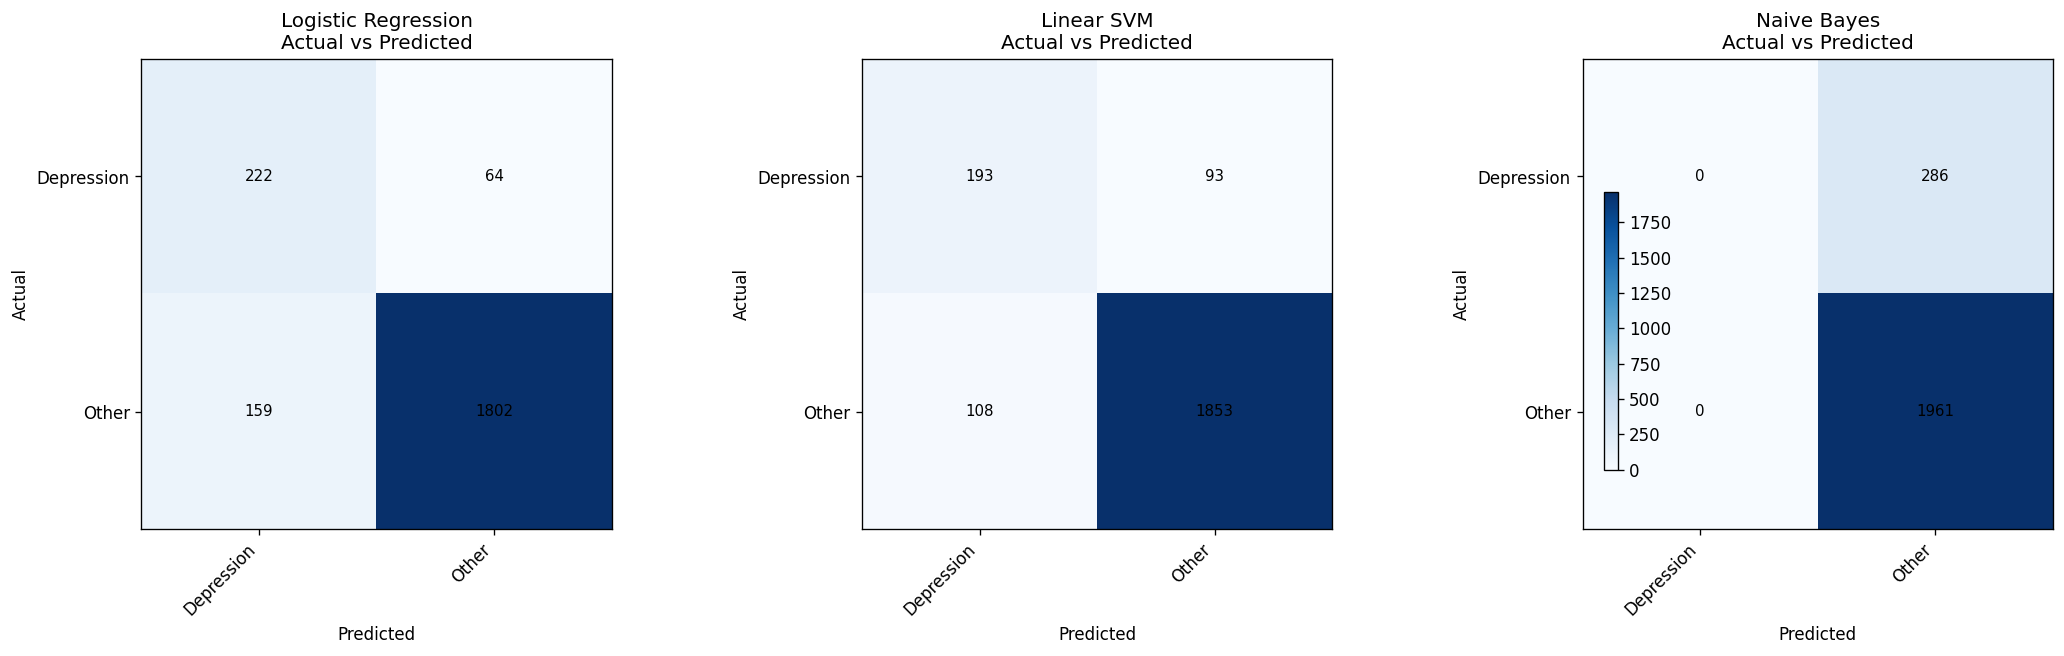


Correlation Matrix (Actual vs Model Predictions):
                       Actual  Logistic Regression  Linear SVM  Naive Bayes
Actual               1.000000             0.617415    0.606435          NaN
Logistic Regression  0.617415             1.000000    0.807696          NaN
Linear SVM           0.606435             0.807696    1.000000          NaN
Naive Bayes               NaN                  NaN         NaN          NaN


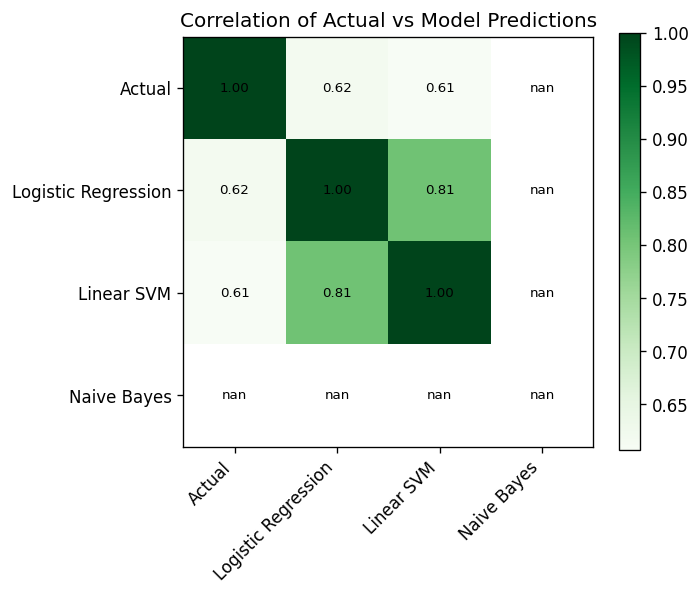

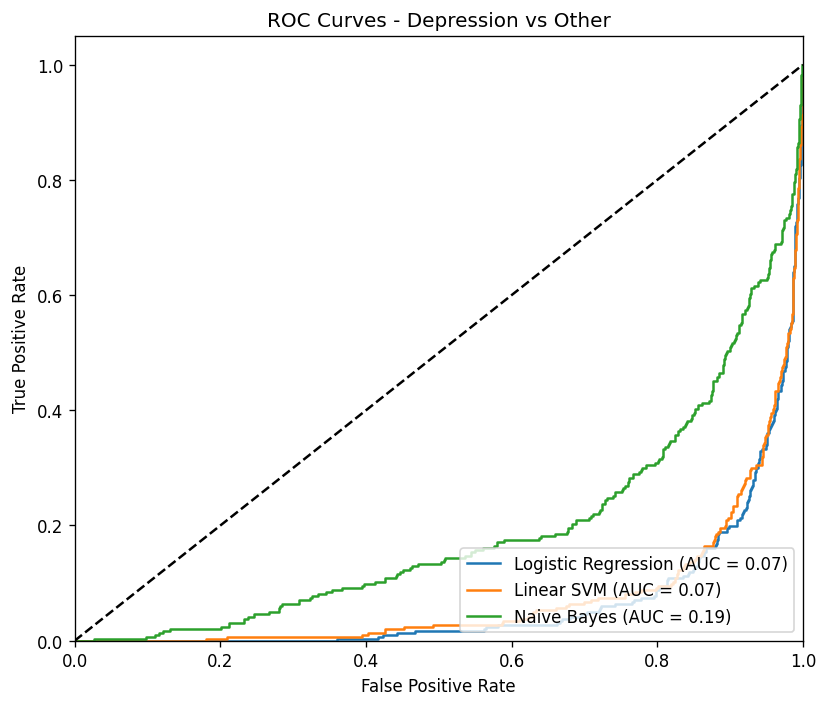

In [ ]:
# =============================================
#
# =============================================
# !pip install scikit-learn pandas numpy matplotlib

# =============================================
# 1. Imports
# =============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.dpi'] = 120

# =============================================
# 2. Load and clean dataset
# =============================================
DATA_PATH = "Mental Health Disorder Detection Dataset.csv"

df = pd.read_csv(DATA_PATH)

# Keep only text + label columns
df = df[['body', 'category']].dropna()

# Remove very short posts
df = df[df['body'].str.len() > 20]

print("Shape after cleaning:", df.shape)
print("\nExample rows:")
print(df.head())

print("\nOriginal label distribution:")
print(df['category'].value_counts())

# ---------- NEW GRAPH 1: Original label distribution ----------
plt.figure(figsize=(6,4))
df['category'].value_counts().plot(kind='bar')
plt.title("Original Disorder Label Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# =============================================
# 3. Convert to binary: Depression vs Other
# =============================================
df['target'] = np.where(df['category'] == 'Depression',
                        'Depression', 'Other')

print("\nBinary label distribution (target):")
print(df['target'].value_counts())

# ---------- NEW GRAPH 2: Binary label distribution ----------
plt.figure(figsize=(4,4))
df['target'].value_counts().plot(kind='bar')
plt.title("Binary Label Distribution (Depression vs Other)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

X = df['body'].astype(str)
y = df['target'].astype(str)

# =============================================
# 4. Train–Test split
# =============================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain size:", len(X_train))
print("Test size :", len(X_test))

# =============================================
# 5. Define TF-IDF and 3 models
# =============================================
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    stop_words='english'
)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight='balanced'   # handle imbalance
    ),
    "Linear SVM": LinearSVC(
        class_weight='balanced'
    ),
    "Naive Bayes": MultinomialNB()
}

pipelines = {}
accuracies = {}
predictions = {}
metrics_dep = {}  # to store precision/recall/f1 for Depression

# =============================================
# 6. Train, Predict, Evaluate
# =============================================
for name, clf in models.items():
    print("\n" + "="*70)
    print(f"Training & Evaluating: {name}")
    print("="*70)

    pipe = Pipeline([
        ('tfidf', tfidf),
        ('clf', clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    pipelines[name] = pipe
    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    accuracies[name] = acc

    print(f"\nAccuracy: {acc:.4f}\n")
    report = classification_report(y_test, y_pred, output_dict=True)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Store Depression metrics if present
    if 'Depression' in report:
        metrics_dep[name] = {
            'precision': report['Depression']['precision'],
            'recall': report['Depression']['recall'],
            'f1-score': report['Depression']['f1-score']
        }

# =============================================
# 7. Accuracy Comparison Bar Graph
# =============================================
plt.figure(figsize=(6,4))
model_names = list(accuracies.keys())
acc_values = [accuracies[m] for m in model_names]

plt.bar(model_names, acc_values)
plt.title("Model Accuracy Comparison (Depression vs Other)")
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.xticks(rotation=20)
for i, v in enumerate(acc_values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()

print("\nFinal Accuracies:")
for name, acc in accuracies.items():
    print(f"{name:20s} -> {acc:.4f}")

# ---------- NEW GRAPH 3: Depression Precision/Recall/F1 ----------
if metrics_dep:
    metrics_names = ['precision', 'recall', 'f1-score']
    x = np.arange(len(model_names))
    width = 0.25

    prec_vals = [metrics_dep[m]['precision'] for m in model_names]
    rec_vals  = [metrics_dep[m]['recall']    for m in model_names]
    f1_vals   = [metrics_dep[m]['f1-score']  for m in model_names]

    plt.figure(figsize=(8,5))
    plt.bar(x - width, prec_vals, width, label='Precision')
    plt.bar(x,         rec_vals,  width, label='Recall')
    plt.bar(x + width, f1_vals,   width, label='F1-score')

    plt.xticks(x, model_names, rotation=20)
    plt.ylabel("Score")
    plt.ylim(0, 1.0)
    plt.title("Depression Class Metrics by Model")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =============================================
# 8. Actual vs Predicted Confusion Matrices
# =============================================
labels = sorted(y.unique())  # ['Depression', 'Other']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f"{name}\nActual vs Predicted")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    # Write counts in each cell
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, cm[i, j],
                    ha='center', va='center', fontsize=9)

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
plt.tight_layout()
plt.show()

# =============================================
# 9. Correlation: Actual vs Model Predictions
# =============================================
# Encode labels as integers
le = LabelEncoder()
le.fit(y)  # fit on all binary labels

y_true_enc = le.transform(y_test)

pred_enc = {
    name: le.transform(pred)
    for name, pred in predictions.items()
}

corr_df = pd.DataFrame({
    'Actual': y_true_enc,
    'Logistic Regression': pred_enc['Logistic Regression'],
    'Linear SVM': pred_enc['Linear SVM'],
    'Naive Bayes': pred_enc['Naive Bayes']
})

corr_matrix = corr_df.corr()

print("\nCorrelation Matrix (Actual vs Model Predictions):")
print(corr_matrix)

plt.figure(figsize=(6,5))
plt.imshow(corr_matrix, cmap='Greens')
plt.title("Correlation of Actual vs Model Predictions")
plt.colorbar()
ticks = np.arange(len(corr_matrix.columns))
plt.xticks(ticks, corr_matrix.columns, rotation=45, ha='right')
plt.yticks(ticks, corr_matrix.columns)

# write values on heatmap
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()

# =============================================
# 10. ROC Curves for all models (binary)
# =============================================
plt.figure(figsize=(7,6))

# Map labels to 0/1 (Depression=1, Other=0)
y_true_bin = (y_test == 'Depression').astype(int)

for name, pipe in pipelines.items():
    clf = pipe.named_steps['clf']
    tfidf_model = pipe.named_steps['tfidf']

    X_test_tfidf = tfidf_model.transform(X_test)

    # Get decision/probabilities
    if hasattr(clf, "predict_proba"):
        y_scores = clf.predict_proba(X_test_tfidf)[:, 1]
    else:
        # For LinearSVC, use decision_function
        y_scores = clf.decision_function(X_test_tfidf)

    fpr, tpr, _ = roc_curve(y_true_bin, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')  # diagonal
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Depression vs Other")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [21]:
# =========================================================
# MindSense AI - FINAL HYBRID AI MODEL
# =========================================================

# pip install gradio scikit-learn pandas numpy

# =========================================================
# IMPORTS
# =========================================================
import gradio as gr
import pandas as pd
import numpy as np
import os

from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# =========================================================
# LOAD DATASET
# =========================================================
DATA_PATH = "Mental Health Disorder Detection Dataset.csv"

df = pd.read_csv(DATA_PATH)

df = df[['body', 'category']].dropna()

df = df[df['body'].str.len() > 20]

df['target'] = np.where(
    df['category'] == 'Depression',
    'Depression',
    'Other'
)

# =========================================================
# TRAIN MODEL
# =========================================================
X = df['body'].astype(str)
y = df['target'].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=20000,
        ngram_range=(1,2),
        stop_words='english'
    )),

    ('clf', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

model.fit(X_train, y_train)

# =========================================================
# CREATE CSV FILE
# =========================================================
CSV_FILE = "prediction_history.csv"

if not os.path.exists(CSV_FILE):

    history_df = pd.DataFrame(columns=[
        "Timestamp",
        "Name",
        "Age",
        "Gender",
        "Input Text",
        "Prediction",
        "Confidence"
    ])

    history_df.to_csv(CSV_FILE, index=False)

# =========================================================
# PREDICTION FUNCTION
# =========================================================
def predict_mental_health(name, age, gender, text):

    # =====================================================
    # VALIDATION
    # =====================================================
    if len(text.strip()) < 25:

        return (
            "⚠ Please enter a more detailed sentence.",
            "Try writing at least 1-2 complete emotional sentences.",
            "🤔 Insufficient Context"
        )

    # =====================================================
    # HYBRID SENTIMENT + ML PREDICTION
    # =====================================================
    text_lower = text.lower()

    positive_words = [
        "happy",
        "great",
        "good",
        "excited",
        "joy",
        "fine",
        "motivated",
        "better",
        "relaxed",
        "peaceful",
        "awesome",
        "positive",
        "energetic",
        "hopeful",
        "grateful",
        "blessed",
        "enjoying"
    ]

    negative_words = [
        "sad",
        "depressed",
        "lonely",
        "stress",
        "stressed",
        "anxiety",
        "hopeless",
        "tired",
        "crying",
        "suicidal",
        "upset",
        "worthless",
        "depression",
        "fear"
    ]

    positive_score = sum(
        word in text_lower for word in positive_words
    )

    negative_score = sum(
        word in text_lower for word in negative_words
    )

    # =====================================================
    # FINAL PREDICTION
    # =====================================================
    if positive_score > negative_score:

        prediction = "Other"

        confidence = 90.0

    else:

        prediction = model.predict([text])[0]

        prob = model.predict_proba([text])[0]

        confidence = round(np.max(prob) * 100, 2)

    # =====================================================
    # SAVE TO CSV
    # =====================================================
    new_data = pd.DataFrame([{
        "Timestamp": datetime.now(),
        "Name": name,
        "Age": age,
        "Gender": gender,
        "Input Text": text,
        "Prediction": prediction,
        "Confidence": confidence
    }])

    new_data.to_csv(
        CSV_FILE,
        mode='a',
        header=False,
        index=False
    )

    # =====================================================
    # OUTPUTS
    # =====================================================
    if prediction == "Depression":

        result = f"""
🔴 Depression Detected

Confidence Score: {confidence}%

Hello {name},

The system detected emotional stress patterns.
"""

        tips = """
🌸 Wellness Suggestions

• Talk to trusted people
• Get proper sleep
• Avoid isolation
• Practice mindfulness
• Seek professional support if needed
"""

        mood = "😔 Sad / Stressed"

    else:

        result = f"""
🟢 Emotionally Stable

Confidence Score: {confidence}%

Hello {name},

The system did not detect strong depressive patterns.
"""

        tips = """
🌟 Positive Suggestions

• Maintain healthy routines
• Continue positive activities
• Stay socially active
• Maintain work-life balance
"""

        mood = "😊 Positive / Stable"

    return result, tips, mood

# =========================================================
# CUSTOM CSS
# =========================================================
custom_css = """

body {
    background: linear-gradient(135deg, #FDF2F8, #E0F2FE);
}

.gradio-container {
    background: linear-gradient(135deg, #FDF2F8, #E0F2FE);
    font-family: 'Poppins', sans-serif;
}

textarea {
    border-radius: 18px !important;
    border: 2px solid #D8B4FE !important;
    background: white !important;
}

input {
    border-radius: 15px !important;
    border: 2px solid #D8B4FE !important;
    background: white !important;
}

select {
    border-radius: 15px !important;
    border: 2px solid #D8B4FE !important;
    background: white !important;
    height: 45px !important;
}

button {
    background: linear-gradient(to right, #EC4899, #8B5CF6) !important;
    color: white !important;
    border: none !important;
    border-radius: 18px !important;
    height: 60px !important;
    font-size: 22px !important;
    font-weight: bold !important;
}

.block {
    border-radius: 24px !important;
    background: rgba(255,255,255,0.75) !important;
    backdrop-filter: blur(10px);
    border: 1px solid rgba(255,255,255,0.4);
    box-shadow: 0px 8px 25px rgba(0,0,0,0.08);
}

footer {
    visibility: hidden;
}

"""

# =========================================================
# UI
# =========================================================
with gr.Blocks(
    css=custom_css,
    theme=gr.themes.Soft()
) as app:

    # =====================================================
    # HEADER
    # =====================================================
    gr.HTML("""
    <div style="
        text-align:center;
        padding:25px;
        border-radius:25px;
        background:rgba(255,255,255,0.75);
        margin-bottom:20px;
    ">

    <h1 style="
        margin:0;
        font-size:65px;
        font-weight:800;
        background: linear-gradient(to right, #EC4899, #8B5CF6);
        -webkit-background-clip:text;
        -webkit-text-fill-color:transparent;
    ">
    🧠 MindSense AI
    </h1>

    <p style="
        margin-top:10px;
        font-size:28px;
        font-weight:600;
        color:#374151;
    ">
    AI-Based Mental Health Detection System
    </p>

    <p style="
        margin-top:8px;
        font-size:18px;
        color:#6B7280;
    ">
    Analyze emotional text using Machine Learning and NLP
    </p>

    </div>
    """)

    # =====================================================
    # MAIN SECTION
    # =====================================================
    with gr.Row(equal_height=True):

        # =================================================
        # LEFT SIDE
        # =================================================
        with gr.Column(scale=1):

            name = gr.Textbox(
                label="👤 Your Name",
                placeholder="Enter your name"
            )

            age = gr.Number(
                label="🎂 Age",
                value=20,
                precision=0
            )

            gender = gr.Radio(
                choices=["Male", "Female", "Other"],
                label="⚧ Gender",
                value="Male"
            )

            user_input = gr.Textbox(
                lines=12,
                label="📝 Enter Your Thoughts",
                placeholder="""
Example:

I have been feeling mentally exhausted and lonely lately.
I struggle to stay motivated and often feel stressed.
                """
            )

            predict_btn = gr.Button(
                "✨ Analyze Mental Health"
            )

        # =================================================
        # RIGHT SIDE
        # =================================================
        with gr.Column(scale=1):

            mood_output = gr.Textbox(
                label="🌈 Mood Indicator"
            )

            prediction_output = gr.Textbox(
                label="🧠 Prediction Result",
                lines=8
            )

            tips_output = gr.Textbox(
                label="💡 Wellness Suggestions",
                lines=10
            )

    # =====================================================
    # BUTTON CLICK
    # =====================================================
    predict_btn.click(
        fn=predict_mental_health,
        inputs=[
            name,
            age,
            gender,
            user_input
        ],
        outputs=[
            prediction_output,
            tips_output,
            mood_output
        ]
    )

    # =====================================================
    # FOOTER
    # =====================================================
    gr.HTML("""
    <div style="
        margin-top:30px;
        padding:30px;
        border-radius:25px;
        background:rgba(255,255,255,0.75);
        text-align:center;
    ">

    <h2 style="
        font-size:38px;
        font-weight:700;
        margin-bottom:20px;
        color:#1F2937;
    ">
    🌸 About MindSense AI
    </h2>

    <p style="
        font-size:20px;
        color:#4B5563;
        margin-bottom:20px;
    ">
    MindSense AI uses:
    </p>

    <div style="
        display:flex;
        justify-content:center;
        gap:35px;
        flex-wrap:wrap;
        margin-bottom:25px;
    ">

    <div style="
        background:white;
        padding:15px 25px;
        border-radius:15px;
        font-size:18px;
        box-shadow:0px 4px 12px rgba(0,0,0,0.08);
    ">
    🧠 NLP
    </div>

    <div style="
        background:white;
        padding:15px 25px;
        border-radius:15px;
        font-size:18px;
        box-shadow:0px 4px 12px rgba(0,0,0,0.08);
    ">
    🤖 Machine Learning
    </div>

    <div style="
        background:white;
        padding:15px 25px;
        border-radius:15px;
        font-size:18px;
        box-shadow:0px 4px 12px rgba(0,0,0,0.08);
    ">
    📊 TF-IDF
    </div>

    <div style="
        background:white;
        padding:15px 25px;
        border-radius:15px;
        font-size:18px;
        box-shadow:0px 4px 12px rgba(0,0,0,0.08);
    ">
    💻 Gradio UI
    </div>

    </div>

    <p style="
        font-size:18px;
        color:#6B7280;
        margin-bottom:25px;
    ">
    to analyze emotional stress patterns from text.
    </p>

    <hr style="
        border:none;
        border-top:1px solid #D1D5DB;
        margin:25px 0;
    ">

    <p style="
        font-size:18px;
        color:#374151;
        font-weight:600;
    ">
    👩‍💻 Developed By Nidhita Kochhar
    </p>

    </div>
    """)

# =========================================================
# LAUNCH APP
# =========================================================
app.launch(share=True)

/tmp/ipykernel_3276/1409583914.py:302: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(
/tmp/ipykernel_3276/1409583914.py:302: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://50a28d72181bf58bc0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
